<div align="center">

<img src="https://javier.rodriguez.org.mx/itesm/2014/tecnologico-de-monterrey-blue.png" width="500"/>

<br>

*Tec de Monterrey Campus Santa Fe*

<br>

*Desarrollo de aplicaciones avanzadas de ciencias computacionales (Gpo 502)*

<br>

*SMS Classification: Ham vs Spam vs Smishing*

<br>

*Profesor*<br>
Ahmed Imad Hammoodi AL-Jarah

<br>

*Alumnos*<br>
Juan Pablo Ruiz de Chávez Diez de Urdanivia A01783127<br>
Marcos Dayan Mann A01782876<br>
Gabriel Edid Harari A01782146

<br>

*Fecha de entrega*<br>
04 de Junio del 2026

In this notebook, we build a model that classifies SMS messages into three classes:
- **ham**: normal legitimate message
- **spam**: unwanted promotional message
- **smishing**: phishing message sent by SMS

We kept the workflow focused on models and preprocessing steps that we can explain clearly in class. The three models we compare are:
1. **Complement Naive Bayes**
2. **Logistic Regression**
3. **Linear SVM**


## 1. Setup

We import the libraries, set a seed for reproducibility, and configure the plots.

In [57]:
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## 2. Load the dataset

The file contains the message text, its label, and three binary columns that indicate whether the original message contains a URL, email, or phone number.

In [58]:
possible_paths = [
    Path('../data/Dataset_10191.csv'),
    Path('data/Dataset_10191.csv'),
] # depending on how you run the notebook, the dataset relative loation may be different

DATA_PATH = None
for candidate in possible_paths:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError('Dataset_10191.csv was not found.')

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv(DATA_PATH)

print('Dataset path:', DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Dataset path: ../data/Dataset_10191.csv
Shape: (10191, 5)
Columns: ['LABEL', 'TEXT', 'URL', 'EMAIL', 'PHONE']


,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,No,No,No
1,ham,Yay can't wait to party together!,No,No,No
2,ham,At what time are you coming.,No,No,No
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",No,No,Yes
4,ham,Yo you around? A friend of mine's lookin to pi...,No,No,No


## 3. Exploratory data analysis

Before training the models, it helps to inspect the dataset first:
- how many messages belong to each class
- how long the messages are
- whether some classes contain more URLs or phone numbers than others


In [59]:
print(df['LABEL'].value_counts())

LABEL
ham         3397
smishing    3397
spam        3397
Name: count, dtype: int64


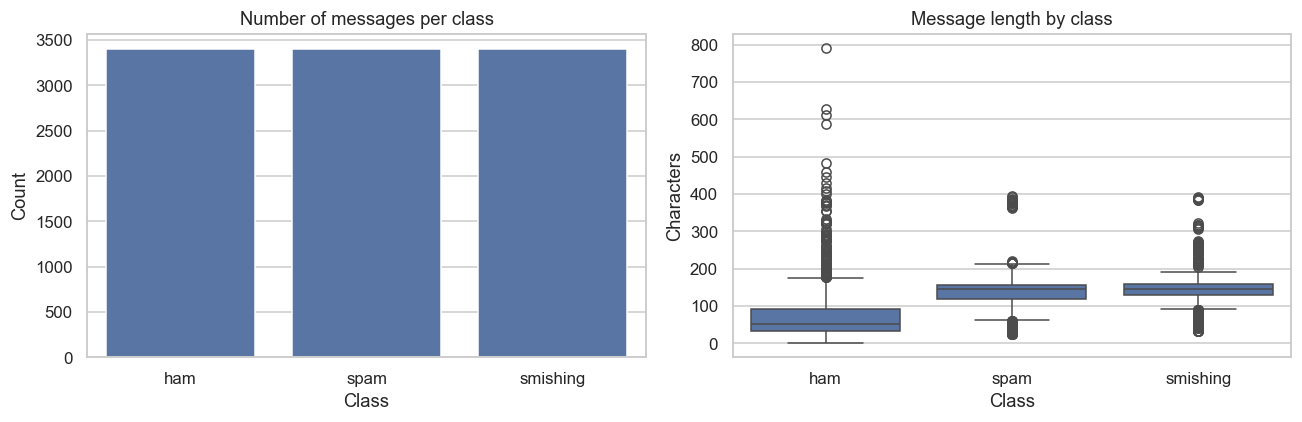

,message_length,word_count
LABEL,,
ham,52.0,11.0
smishing,147.0,24.0
spam,145.0,24.0


In [60]:
df['message_length'] = df['TEXT'].str.len()
df['word_count'] = df['TEXT'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='LABEL', order=['ham', 'spam', 'smishing'], ax=axes[0])
axes[0].set_title('Number of messages per class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

sns.boxplot(data=df, x='LABEL', y='message_length', order=['ham', 'spam', 'smishing'], ax=axes[1])
axes[1].set_title('Message length by class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Characters')

plt.tight_layout()
plt.show()

df.groupby('LABEL')[['message_length', 'word_count']].median().round(1)

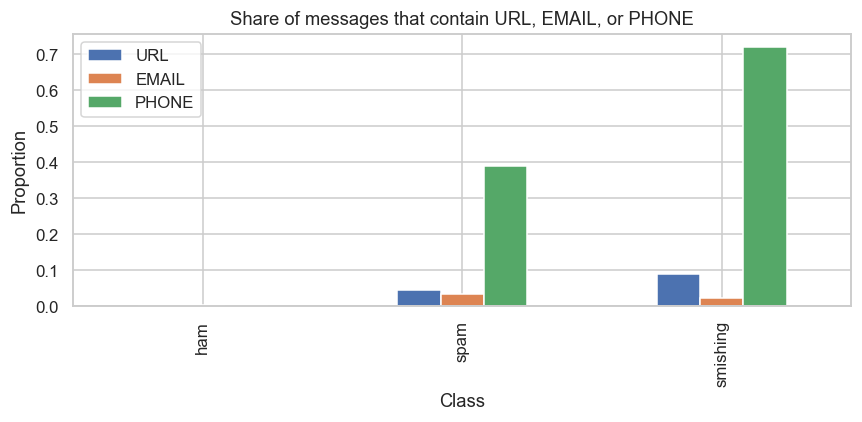

,URL,EMAIL,PHONE
LABEL,,,
ham,0.000,0.002,0.001
spam,0.046,0.032,0.390
smishing,0.089,0.022,0.721


In [61]:
flag_summary = (
    df.assign(
        URL=(df['URL'] == 'Yes').astype(int),
        EMAIL=(df['EMAIL'] == 'Yes').astype(int),
        PHONE=(df['PHONE'] == 'Yes').astype(int),
    )
    .groupby('LABEL')[['URL', 'EMAIL', 'PHONE']]
    .mean()
    .loc[['ham', 'spam', 'smishing']]
)

ax = flag_summary.plot(kind='bar', figsize=(8, 4))
ax.set_title('Share of messages that contain URL, EMAIL, or PHONE')
ax.set_xlabel('Class')
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()

flag_summary.round(3)

### Findings from the exploratory analysis

From the class count table, we can see that the dataset is perfectly balanced, with 3,397 messages for each label. This is useful because the models are not biased toward one class just because it appears more often.

From the message length and word count plots, we can see a clear difference between ham and the two malicious classes. Ham messages tend to be much shorter. Its median message length is about **52 characters** and its median word count is **11 words**. In contrast, both spam and smishing are much longer, with median lengths close to **145 to 147 characters** and median word counts around **24 words**.

The URL, email, and phone indicators also show an interesting pattern. Ham messages almost never contain these elements. Spam messages contain phones more often, but smishing has the strongest phone signal by far. Around **72.1%** of smishing messages contain a phone number, compared with **39.0%** in spam and almost none in ham. This matches the idea that many smishing messages try to push the user to call a number or contact a fake service.

Overall, the EDA suggests that ham is easier to separate, while the harder decision will probably be distinguishing **spam** from **smishing**, since both classes share suspicious language and longer message formats.


## 4. Text preprocessing

The model cannot use raw text directly, so we clean the messages first.

### Steps used here
- convert text to lowercase
- replace URLs with the token `__url__`
- replace emails with the token `__email__`
- replace phone numbers with the token `__phone__`
- remove repeated spaces

This makes the text more consistent while keeping useful patterns for classification.


In [62]:
URL_RE = re.compile(r'(https?://\S+|www\.\S+)')
EMAIL_RE = re.compile(r'\b[\w.+-]+@[\w-]+\.[\w.-]+\b')
PHONE_RE = re.compile(r'(\+?\d[\d\-\s().]{6,}\d)')


def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(' __url__ ', text)
    text = EMAIL_RE.sub(' __email__ ', text)
    text = PHONE_RE.sub(' __phone__ ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['TEXT'].apply(clean_text)

df[['TEXT', 'clean_text']].head(5)

,TEXT,clean_text
0,Hi! You just spoke to DEEPAK. We'd like to kno...,hi! you just spoke to deepak. we'd like to kno...
1,Yay can't wait to party together!,yay can't wait to party together!
2,At what time are you coming.,at what time are you coming.
3,"Dear customer your PAY2TMKYC has been expired,...","dear customer your pay2tmkyc has been expired,..."
4,Yo you around? A friend of mine's lookin to pi...,yo you around? a friend of mine's lookin to pi...


## 5. Label encoding and numeric features

Scikit-learn models work with numeric labels, so the classes are converted from text into integers.

We also add a few simple numeric features from each message:
- message length
- word count
- digit count
- exclamation count

These features are simple, easy to explain, and can help separate normal messages from suspicious ones, based on the pattern and the structure some of this messages follow


In [63]:
from sklearn.preprocessing import LabelEncoder


def numeric_features(text):
    text = str(text)
    return pd.Series({
        'digit_count': sum(char.isdigit() for char in text),
        'exclamation_count': text.count('!'),
    })


extra_features = df['TEXT'].apply(numeric_features)
df = pd.concat([df, extra_features], axis=1)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['LABEL'])
LABEL_NAMES = list(label_encoder.classes_)

NUMERIC_COLS = ['message_length', 'word_count', 'digit_count', 'exclamation_count']
FEATURE_COLS = ['clean_text'] + NUMERIC_COLS

print('Label mapping:', dict(zip(LABEL_NAMES, range(len(LABEL_NAMES)))))
df[FEATURE_COLS + ['LABEL', 'label']].head()

Label mapping: {'ham': 0, 'smishing': 1, 'spam': 2}


,clean_text,message_length,word_count,digit_count,exclamation_count,LABEL,label
0,hi! you just spoke to deepak. we'd like to kno...,122,24,0,1,ham,0
1,yay can't wait to party together!,33,6,0,1,ham,0
2,at what time are you coming.,28,6,0,0,ham,0
3,"dear customer your pay2tmkyc has been expired,...",150,23,14,1,smishing,1
4,yo you around? a friend of mine's lookin to pi...,65,13,0,0,ham,0


## 6. Train/test split

We separate the dataset into training and testing sets.

`stratify=y` means both splits keep the same class proportion as the original dataset. That is important for a fair evaluation.

In [64]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])
print('Training class counts:', np.bincount(y_train))
print('Testing class counts:', np.bincount(y_test))

Training samples: 8152
Testing samples: 2039
Training class counts: [2718 2717 2717]
Testing class counts: [679 680 680]


## 7. Build the preprocessing pipeline

This is the main scikit-learn block we will use.

### `TfidfVectorizer`
This converts text into numeric vectors. Each message is represented by the words it contains, and TF-IDF gives more importance to words that are informative for classification.

### `ColumnTransformer`
This lets us apply different preprocessing steps to different columns:
- TF-IDF to the text column
- scaling to the numeric columns

After that, it combines everything into a single feature matrix.

### `Pipeline`
A pipeline joins preprocessing and the classifier in one object. This makes the training and prediction process cleaner, because the same steps are applied every time.


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                'text_tfidf',
                TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2),
                'clean_text',
            ),
            (
                'numeric_data',
                MaxAbsScaler(),
                NUMERIC_COLS,
            ),
        ]
    )


models = {
    'Complement Naive Bayes': ComplementNB(alpha=0.5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Linear SVM': LinearSVC(random_state=SEED),
}

## 8. Train the models

Here we train the three models and compare them with two metrics:
- **accuracy**: the proportion of correct predictions
- **macro F1**: the average F1 score across the three classes

Since the dataset is balanced, macro F1 is a useful metric for comparing performance across all classes.


In [66]:
predictions = {}
fitted_models = {}
results = []

for model_name, classifier in models.items():
    model = Pipeline(
        steps=[
            ('preprocessor', build_preprocessor()),
            ('classifier', classifier),
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred
    fitted_models[model_name] = model
    results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
    })

results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
results_df.round(4)

,model,accuracy,macro_f1
0,Linear SVM,0.9789,0.9789
1,Logistic Regression,0.9681,0.9682
2,Complement Naive Bayes,0.9578,0.9580


## 9. Detailed evaluation

After training, we look at the results in more detail using:
- a classification report
- a confusion matrix

The confusion matrix is useful because it shows which classes are being confused with each other.


In [67]:
from sklearn.metrics import classification_report, confusion_matrix

for model_name, y_pred in predictions.items():
    print('=' * 70)
    print(model_name)
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=4))

Complement Naive Bayes
              precision    recall  f1-score   support

         ham     0.9970    0.9661    0.9813       679
    smishing     0.9289    0.9603    0.9443       680
        spam     0.9499    0.9471    0.9485       680

    accuracy                         0.9578      2039
   macro avg     0.9586    0.9578    0.9580      2039
weighted avg     0.9585    0.9578    0.9580      2039

Logistic Regression
              precision    recall  f1-score   support

         ham     0.9911    0.9867    0.9889       679
    smishing     0.9714    0.9485    0.9598       680
        spam     0.9428    0.9691    0.9558       680

    accuracy                         0.9681      2039
   macro avg     0.9684    0.9681    0.9682      2039
weighted avg     0.9684    0.9681    0.9682      2039

Linear SVM
              precision    recall  f1-score   support

         ham     1.0000    0.9971    0.9985       679
    smishing     0.9818    0.9544    0.9679       680
        spam     0.95

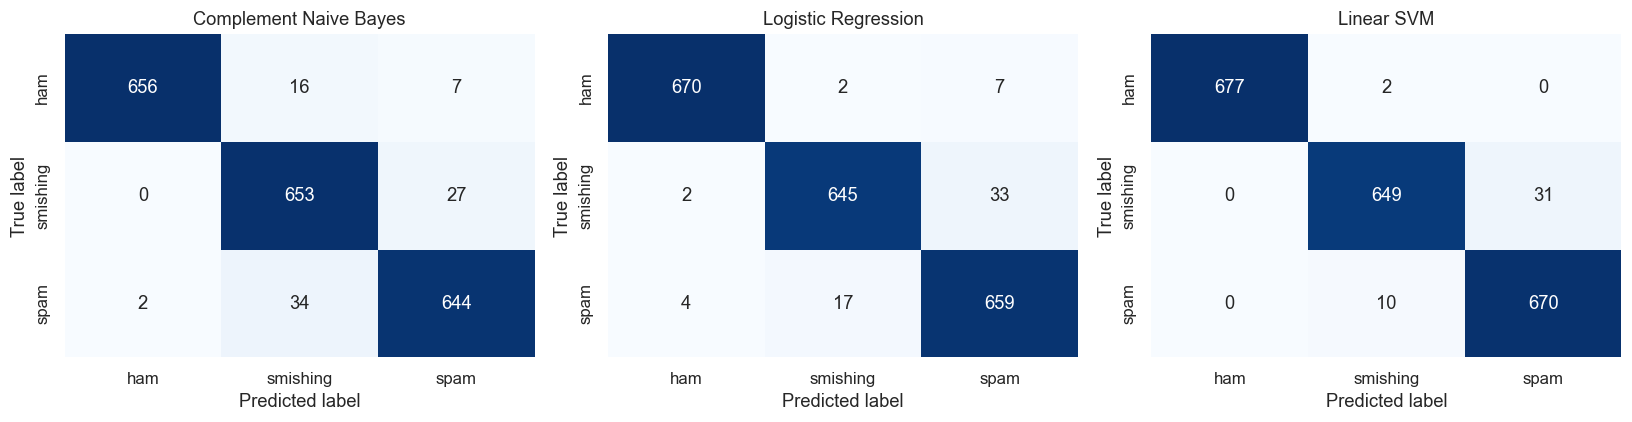

In [68]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))

if len(predictions) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.show()

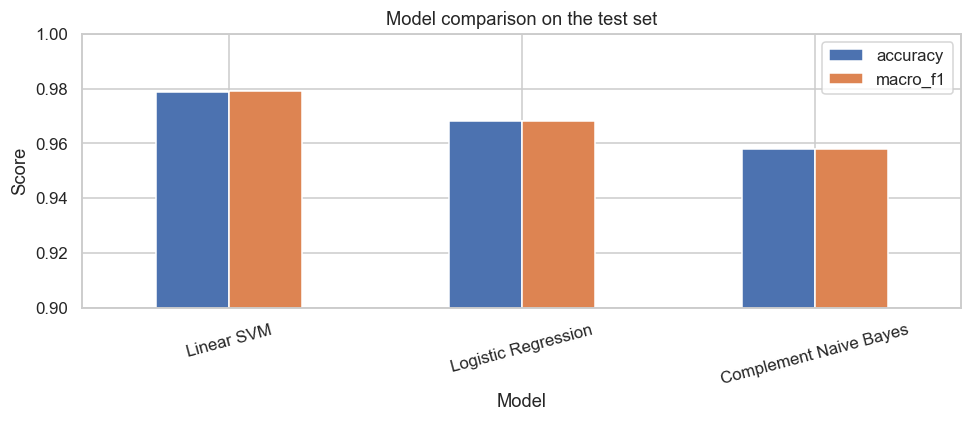

Best model: Linear SVM


In [69]:
ax = results_df.plot(kind='bar', x='model', y=['accuracy', 'macro_f1'], figsize=(9, 4))
ax.set_title('Model comparison on the test set')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0.90, 1.00)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['model']
print('Best model:', best_model_name)

### Findings from the model comparison

The comparison table shows that all three models perform well, but **Linear SVM** gives the best results, with test accuracy and macro F1 close to **0.979**. **Logistic Regression** comes next with macro F1 close to **0.968**, and **Complement Naive Bayes** is slightly lower, around **0.958**.

This tells us that the text patterns in the dataset can be captured very well with standard TF-IDF features. In other words, we do not need a very complex model to get strong results here.

From the classification reports and confusion matrices, we can also see that **ham** is the easiest class to classify. The remaining mistakes are mostly between **spam** and **smishing**, which makes sense because both types of messages can include offers, urgent language, links, phone numbers, or requests for action.

A practical conclusion from this section is that **Linear SVM** is the best option for this notebook because it combines high accuracy with a workflow that is still easy to explain.


## 10. Try the best model with new example messages

This section tests the best model with a larger set of example messages that were not taken from the dataset.


In [73]:
def build_feature_frame(messages):
    new_df = pd.DataFrame({'TEXT': messages})
    new_df['clean_text'] = new_df['TEXT'].apply(clean_text)
    new_df['message_length'] = new_df['TEXT'].str.len()
    new_df['word_count'] = new_df['TEXT'].str.split().apply(len)
    extra = new_df['TEXT'].apply(numeric_features)
    new_df = pd.concat([new_df, extra], axis=1)
    return new_df[FEATURE_COLS]


example_messages = [
    "Hey, are we still meeting at 7 pm after class?",  # ham
    "Can you send me the notes from today's lecture when you have time?",  # ham
    "I am outside the library, let us know when you arrive.",  # ham
    "Congratulations! You won a free vacation. Call now to claim your prize!",  # smishing
    "Limited time offer! Get 50% off on all products. Visit https://fake-store.com now!",  # spam
    "You have been selected for an exclusive cashback reward. Reply YES now!",  # spam
    "Your bank account will be suspended today. Verify now at http://fake-link.com",  # smishing
    "Dear customer, your payment account has been locked. Call 8001234567 immediately to restore access.",  # smishing
    "Notice: your package delivery failed. Update your address here: http://track-package-now.com",  # smishing
    "Hey bro, are you coming to the party tonight? Did you purchased your ticket at https://ticket-portal.com ?",  # ham
]

labels = [
    "ham",
    "ham",
    "ham",
    "smishing",
    "spam",
    "spam",
    "smishing",
    "smishing",
    "smishing",
    "ham",
]

best_model = fitted_models[best_model_name]
example_features = build_feature_frame(example_messages)
example_predictions = best_model.predict(example_features)
example_labels = label_encoder.inverse_transform(example_predictions)

pd.DataFrame({
    'message': example_messages,
    'predicted_label': example_labels,
    'true_label': labels,
})


,message,predicted_label,true_label
0,"Hey, are we still meeting at 7 pm after class?",ham,ham
1,Can you send me the notes from today's lecture...,ham,ham
2,"I am outside the library, let us know when you...",ham,ham
3,Congratulations! You won a free vacation. Call...,smishing,smishing
4,Limited time offer! Get 50% off on all product...,spam,spam
5,You have been selected for an exclusive cashba...,ham,spam
6,Your bank account will be suspended today. Ver...,smishing,smishing
7,"Dear customer, your payment account has been l...",smishing,smishing
8,Notice: your package delivery failed. Update y...,smishing,smishing
9,"Hey bro, are you coming to the party tonight? ...",ham,ham


### Notes on the example predictions

This section is useful because it shows how the trained model reacts to messages outside the dataset table. We included normal messages, promotional messages, and suspicious messages with links, prizes, account alerts, and payment requests.

These examples help us check whether the model behavior is consistent with the patterns seen during the exploratory analysis and the evaluation stage.


## 11. Conclusion

By working on this project, we found and learned the following:

- For this dataset, **Logistic Regression** and **Linear SVM** are strong and easy to explain choices.
- `TF-IDF vectorizer` does a good job on encoding words to numerical features, since it considers term frequency and document frequency
- The dataset we chose is balanced and it has a good amount of examples, so the model comparison is fair across the three classes.
- Smishing messages stand out because they contain phone numbers much more often than the other classes.
- Although we initially thought Naive Bayes algorithm would excel on performance since this model is mainly used for natural language prediction and classification, the best result in this notebook comes from Linear SVM, which performs better than the other two models on the test set.
- Most of the remaining classification errors happen between spam and smishing, not between ham and the malicious classes. After analyzing some data examples, spam and smishing messages tend to me more similar than ham messages, because of the message structure and length, but also because of which words are used, and the context and combination of the words
- Future work on this would be to research on how can we distinguish and classify between two similar natural language content types, for example, between types of spam